In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install torch torchvision matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd "/content/drive/MyDrive/neuro"

/content/drive/MyDrive/neuro


In [68]:
data = pd.read_csv("/content/drive/MyDrive/neuro/Dataset_with_Trial_IDs (1).csv")

<ipython-input-68-bfdf36c34a35>:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/neuro/Dataset_with_Trial_IDs (1).csv")


In [69]:
data = data[["timestamp","cursor_pos","cursor_pos.1"]]
data = data.iloc[1:].reset_index(drop=True)
data.head(5)

,timestamp,cursor_pos,cursor_pos.1
0,0.001,-2.445708618379075,1.8065088368179838
1,0.002,-4.355809171967876,3.254141150437025
2,0.003,-3.806003535898849,2.7645346453592574
3,0.004,-4.131651046760463,2.992293143066401
4,0.005,-3.9004592846162294,2.7288211578060557


In [23]:
data.columns

Index(['timestamp', 'cursor_pos', 'cursor_pos.1', 'eye_pos', 'eye_pos.1',
       'hand_pos', 'hand_pos.1', 'hand_vel', 'hand_vel.1', 'spikes',
       ...
       'spikes.133', 'spikes.134', 'spikes.135', 'spikes.136', 'spikes.137',
       'spikes.138', 'spikes.139', 'spikes.140', 'spikes.141', 'trial_id'],
      dtype='object', length=152)

In [70]:
trial = pd.read_csv("Trials.csv")
trial = trial[["start_time","stop_time","maze_id","trial_type","barrier_pos","target_pos"]]
trial.head(5)



,start_time,stop_time,maze_id,trial_type,barrier_pos,target_pos
0,0.0,3.421,76,11,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
1,3.5,5.631,77,12,[],[[-77 82]]
2,5.7,8.536,4,4,[[ 100 38 63 14]\n [-146 90 54 10]...,[[-100 35]]
3,8.6,11.746,10,8,[[-119 48 72 8]\n [ -47 68 9 20]...,[[-92 81]\n [-91 -70]\n [117 15]]
4,11.8,14.706,8,7,[[-119 48 72 8]\n [ -47 68 9 20]...,[[-92 81]\n [-91 -70]\n [117 15]]


In [71]:
trial = trial.sort_values('start_time')
data = data.sort_values('timestamp')

In [33]:
trial

,start_time,stop_time,maze_id,trial_type,barrier_pos,target_pos
0,0.0,3.421,76,11,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
1,3.5,5.631,77,12,[],[[-77 82]]
2,5.7,8.536,4,4,[[ 100 38 63 14]\n [-146 90 54 10]...,[[-100 35]]
3,8.6,11.746,10,8,[[-119 48 72 8]\n [ -47 68 9 20]...,[[-92 81]\n [-91 -70]\n [117 15]]
4,11.8,14.706,8,7,[[-119 48 72 8]\n [ -47 68 9 20]...,[[-92 81]\n [-91 -70]\n [117 15]]
...,...,...,...,...,...,...
95,278.6,282.021,76,11,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[ 133 -81]\n [-118 -83]\n [ -77 82]]
96,282.1,284.466,4,4,[],[[-100 35]]
97,284.5,287.376,3,3,[[ 100 38 63 14]\n [-146 90 54 10]...,[[-100 35]\n [ 125 -64]\n [ 104 80]]
98,287.4,290.736,3,3,[[ 100 38 63 14]\n [-146 90 54 10]...,[[125 -64]]


In [73]:
for i, row in data.iterrows():
    ts = row['timestamp']  # Use the timestamp value of the current row

    match = trial[(trial['start_time'] <= ts) & (ts <= trial['stop_time'])] # Changed the >= to <= for the start time condition

    if not match.empty:
        # If multiple matches, pick the first
        data.at[i, 'trial_type'] = match.iloc[0]['trial_type']
        data.at[i, 'barrier_pos'] = match.iloc[0]['barrier_pos']
        data.at[i, 'target_pos'] = match.iloc[0]['target_pos']

In [74]:
data

,timestamp,cursor_pos,cursor_pos.1,trial_type,barrier_pos,target_pos
0,0.001,-2.445708618379075,1.8065088368179838,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
1,0.002,-4.355809171967876,3.254141150437025,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
2,0.003,-3.806003535898849,2.7645346453592574,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
3,0.004,-4.131651046760463,2.992293143066401,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
4,0.005,-3.9004592846162294,2.7288211578060557,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
...,...,...,...,...,...,...
58729,58.730,-113.721973,-77.212775,7.0,[],[[-92 81]]
58730,58.731,-120.190982,-81.605331,7.0,[],[[-92 81]]
58731,58.732,-110.952083,-75.40675,7.0,[],[[-92 81]]
58732,58.733,-126.4276,-85.79146,7.0,[],[[-92 81]]


In [75]:
data.to_csv("matched_pos.csv")

In [42]:
data = pd.read_csv("matched_pos.csv")

In [47]:
data["trial_type"].unique()

array([11., nan, 12.,  4.,  8.,  7.,  6.,  3., 10.,  2.])

In [51]:
len(data)

56562

In [50]:
data = data.dropna()

In [ ]:
import pandas as pd
import numpy as np

sequence_length = 5
sequences = []

# Drop the first row


# Forward-fill NaNs
data[["cursor_pos", "cursor_pos.1","trial_type"]] = data[["cursor_pos", "cursor_pos.1","trial_type"]].ffill()

# Drop remaining NaNs (just in case)
data = data.dropna(subset=["cursor_pos", "cursor_pos.1"])

# Extract coordinates
# coords = data[["cursor_pos", "cursor_pos.1"]].values
coords = data[["cursor_pos", "cursor_pos.1"]].values.astype(float)

for i in range(len(coords) - sequence_length + 1):
    sequences.append(coords[i:i + sequence_length])

# Final stack
sequences = np.stack(sequences)
print("Final shape:", sequences.shape)


Final shape: (58730, 5, 2)


In [53]:
import pandas as pd
import numpy as np

sequence_length = 5
sequences = []
labels = []

# Forward-fill NaNs
data[["cursor_pos", "cursor_pos.1", "trial_type"]] = data[["cursor_pos", "cursor_pos.1", "trial_type"]].ffill()

# Drop remaining NaNs (just in case)
data = data.dropna(subset=["cursor_pos", "cursor_pos.1"])

# Convert to float
data[["cursor_pos", "cursor_pos.1"]] = data[["cursor_pos", "cursor_pos.1"]].astype(float)

# Group by trial_type
grouped = data.groupby("trial_type")

for trial_id, group in grouped:
    coords = group[["cursor_pos", "cursor_pos.1"]].values

    # Skip if not enough for one full sequence
    if len(coords) < sequence_length:
        continue

    for i in range(len(coords) - sequence_length + 1):
        seq = coords[i:i + sequence_length]
        sequences.append(seq)
        labels.append(trial_id)

# Convert to arrays
sequences = np.stack(sequences)
labels = np.array(labels)



In [ ]:
# import pandas as pd
# import numpy as np

# sequence_length = 50
# sequences = []

# # Drop the first row
# data = data.iloc[1:].reset_index(drop=True)

# # Forward-fill NaNs
# data[["hand_pos", "hand_pos.1"]] = data[["hand_pos", "hand_pos.1"]].ffill()

# # Drop remaining NaNs (just in case)
# data = data.dropna(subset=["hand_pos", "hand_pos.1"])

# # Extract coordinates
# coords = data[["hand_pos", "hand_pos.1"]].values

# # Create overlapping sequences
# for i in range(len(coords) - sequence_length + 1):
#     sequences.append(coords[i:i + sequence_length])

# # Final stack
# sequences = np.stack(sequences)
# print("Final shape:", sequences.shape)


Final shape: (58684, 50, 2)


In [ ]:
# import pandas as pd
# import numpy as np

# sequence_length = 5
# sequences = []

# # Drop first row and forward-fill
# data = data.iloc[1:].reset_index(drop=True)
# data[["cursor_pos", "cursor_pos.1"]] = data[["cursor_pos", "cursor_pos.1"]].ffill()
# data = data.dropna(subset=["cursor_pos", "cursor_pos.1"])

# # Extract as float
# coords = data[["cursor_pos", "cursor_pos.1"]].values.astype(float)

# # Build and normalize each sequence individually
# for i in range(len(coords) - sequence_length + 1):
#     seq = coords[i:i + sequence_length]
#     mean = seq.mean(axis=0)
#     std = seq.std(axis=0) + 1e-8  # prevent division by zero
#     norm_seq = (seq - mean) / std
#     sequences.append(norm_seq)

# sequences = np.stack(sequences)
# print("Final shape:", sequences.shape)


Final shape: (58728, 5, 2)


In [ ]:
import numpy as np

sequences = np.stack(sequences)  # shape: (num_sequences, sequence_length, 2)

print("Shape of dataset:", sequences.shape)
# Example: (1200, 100, 2)


Shape of dataset: (58730, 5, 2)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Split into train/val/test (e.g. 80/10/10)
train, temp = train_test_split(sequences, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

# Save as compressed .npz
np.savez_compressed("trajectory_dataset.npz", train=train, val=val, test=test)

print("✅ Dataset saved as trajectory_dataset.npz")


✅ Dataset saved as trajectory_dataset.npz


In [54]:
import numpy as np
from sklearn.model_selection import train_test_split

# Assume these are already defined:
# sequences: List or np.array of shape (num_trials, T, 2)
# labels: List or np.array of shape (num_trials,) with maze IDs or trial types

# Combine sequences and labels
data = list(zip(sequences, labels))

# Split into train/val/test
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Unzip sequences and labels
train_seqs, train_labels = zip(*train_data)
val_seqs, val_labels = zip(*val_data)
test_seqs, test_labels = zip(*test_data)

# Convert to NumPy arrays
train_seqs = np.array(train_seqs)
val_seqs = np.array(val_seqs)
test_seqs = np.array(test_seqs)

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_labels)

# Save as compressed .npz
np.savez_compressed("trajectory_dataset.npz",
                    train=train_seqs,
                    val=val_seqs,
                    test=test_seqs,
                    train_labels=train_labels,
                    val_labels=val_labels,
                    test_labels=test_labels)

print("✅ Dataset and labels saved in trajectory_dataset.npz")


✅ Dataset and labels saved in trajectory_dataset.npz


In [ ]:
import numpy as np

data = np.load("trajectory_dataset.npz")
for split in ["train", "val", "test"]:
    arr = data[split]
    print(f"{split} shape: {arr.shape}")
    print(f"{split} contains NaN:", np.isnan(arr).any())
    print(f"{split} contains Inf:", np.isinf(arr).any())
    print(f"{split} max:", np.max(arr), "min:", np.min(arr))


train shape: (46984, 5, 2)
train contains NaN: False
train contains Inf: False
train max: 155.49038839003495 min: -135.59371445898796
val shape: (5873, 5, 2)
val contains NaN: False
val contains Inf: False
val max: 155.49038839003495 min: -135.30341205486602
test shape: (5873, 5, 2)
test contains NaN: False
test contains Inf: False
test max: 155.49038839003495 min: -135.59371445898796


MODEL

In [ ]:
print("Using device:", device)

Using device: cuda


In [55]:
# DDPM for 2D Trajectory Generation (pos x, pos y)
# Sequence length: T, Feature dim: 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
import os

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, timesteps):
        device = timesteps.device
        half_dim = self.dim // 2
        emb = torch.exp(
            torch.arange(half_dim, device=device) * (-torch.log(torch.tensor(10000.0)) / half_dim)
        )
        emb = timesteps[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class TrajectoryUNet(nn.Module):
    def __init__(self, seq_len=100, dim=64):
        super().__init__()
        self.seq_len = seq_len
        self.dim = dim

        self.time_embed = SinusoidalPositionEmbeddings(dim)
        self.input_proj = nn.Conv1d(2, dim, kernel_size=1)

        self.net = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(dim, dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(dim, 2, kernel_size=1)  # (B, 2, T)
        )

    def forward(self, x, t):
        # x: (B, T, 2) -> (B, 2, T)
        x = x.permute(0, 2, 1)
        time_emb = self.time_embed(t)  # (B, dim)
        time_emb = time_emb[:, :, None]  # (B, dim, 1)

        x = self.input_proj(x) + time_emb  # (B, dim, T)
        x = self.net(x)  # (B, 2, T)
        return x.permute(0, 2, 1)  # back to (B, T, 2)


class GaussianDiffusion(nn.Module):
    def __init__(self, model, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.model = model
        self.timesteps = timesteps

        betas = torch.linspace(beta_start, beta_end, timesteps)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', 1. - betas)
        self.register_buffer('alphas_cumprod', torch.cumprod(1. - betas, dim=0))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod[t])[:, None, None]
        sqrt_one_minus = torch.sqrt(1 - self.alphas_cumprod[t])[:, None, None]
        return sqrt_alphas_cumprod * x_start + sqrt_one_minus * noise

    def p_losses(self, x_start, t):
        noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start=x_start, t=t, noise=noise)
        predicted_noise = self.model(x_noisy, t)
        return F.mse_loss(predicted_noise, noise)

    def sample(self, shape, device):
        x = torch.randn(shape, device=device)
        for t in reversed(range(self.timesteps)):
            t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)
            predicted_noise = self.model(x, t_batch)
            beta_t = self.betas[t]
            alpha_t = self.alphas[t]
            alpha_bar_t = self.alphas_cumprod[t]

            x = (1 / torch.sqrt(alpha_t)) * (
                x - beta_t / torch.sqrt(1 - alpha_bar_t) * predicted_noise
            )
            if t > 0:
                noise = torch.randn_like(x)
                x += torch.sqrt(beta_t) * noise
        return x

# --- Training Code ---
def train_ddpm(model, dataset_path="trajectory_dataset.npz", epochs=20, batch_size=32, lr=1e-4, device="cuda", save_path="ddpm_model.pt"):
    # data = np.load(dataset_path)
    # train_data = torch.tensor(data["train"], dtype=torch.float32)
    # val_data = torch.tensor(data["val"], dtype=torch.float32)
    # test_data = torch.tensor(data["test"], dtype=torch.float32)
    data = np.load(dataset_path, allow_pickle=True)

    # Load sequences and labels
    train_data = torch.tensor(data["train"].astype(np.float32), dtype=torch.float32)
    val_data = torch.tensor(data["val"].astype(np.float32), dtype=torch.float32)
    test_data = torch.tensor(data["test"].astype(np.float32), dtype=torch.float32)

    train_labels = torch.tensor(data["train_labels"], dtype=torch.long)
    val_labels = torch.tensor(data["val_labels"], dtype=torch.long)
    test_labels = torch.tensor(data["test_labels"], dtype=torch.long)

    # Create loaders (labels not used during training for now)
    train_loader = DataLoader(TensorDataset(train_data, train_labels), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(val_data, val_labels), batch_size=batch_size)

    diffusion = GaussianDiffusion(model).to(device)
    optimizer = torch.optim.Adam(diffusion.parameters(), lr=lr)

    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            x = batch[0].to(device)
            t = torch.randint(0, diffusion.timesteps, (x.size(0),), device=device).long()
            loss = diffusion.p_losses(x, t)

            if torch.isnan(loss):
                print(" NaN loss detected. Skipping batch.")
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / max(len(train_loader), 1)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device)
                t = torch.randint(0, diffusion.timesteps, (x.size(0),), device=device).long()
                loss = diffusion.p_losses(x, t)
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'diffusion_state_dict': diffusion.state_dict()
            }, "/content/drive/MyDrive/neuro/ddpm_model.pt")
            print(f" Full model saved to {save_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} due to no improvement in validation loss.")
                break

    # Test
    test_loader = DataLoader(TensorDataset(test_data), batch_size=batch_size)
    with torch.no_grad():
        test_loss = 0
        for batch in test_loader:
            x = batch[0].to(device)
            t = torch.randint(0, diffusion.timesteps, (x.size(0),), device=device).long()
            loss = diffusion.p_losses(x, t)
            test_loss += loss.item()

        print(f"Test Loss: {test_loss / max(len(test_loader), 1):.4f}")

    return diffusion


# --- Example usage ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TrajectoryUNet()
    trained_diffusion = train_ddpm(model, device=device)



Epoch 1/20, Train Loss: 0.7101
Epoch 1/20, Val Loss: 0.5542
 Full model saved to ddpm_model.pt
Epoch 2/20, Train Loss: 0.5143
Epoch 2/20, Val Loss: 0.4798
 Full model saved to ddpm_model.pt
Epoch 3/20, Train Loss: 0.4709
Epoch 3/20, Val Loss: 0.4345
 Full model saved to ddpm_model.pt
Epoch 4/20, Train Loss: 0.4387
Epoch 4/20, Val Loss: 0.4144
 Full model saved to ddpm_model.pt
Epoch 5/20, Train Loss: 0.4144
Epoch 5/20, Val Loss: 0.3937
 Full model saved to ddpm_model.pt
Epoch 6/20, Train Loss: 0.4023
Epoch 6/20, Val Loss: 0.3915
 Full model saved to ddpm_model.pt
Epoch 7/20, Train Loss: 0.3881
Epoch 7/20, Val Loss: 0.3708
 Full model saved to ddpm_model.pt
Epoch 8/20, Train Loss: 0.3832
Epoch 8/20, Val Loss: 0.3748
Epoch 9/20, Train Loss: 0.3743
Epoch 9/20, Val Loss: 0.3792
Epoch 10/20, Train Loss: 0.3693
Epoch 10/20, Val Loss: 0.3509
 Full model saved to ddpm_model.pt
Epoch 11/20, Train Loss: 0.3610
Epoch 11/20, Val Loss: 0.3612
Epoch 12/20, Train Loss: 0.3583
Epoch 12/20, Val Loss: 0

In [ ]:
def load_ddpm_model(model_path="ddpm_model.pt", device="cuda"):
    # 1. Recreate the architecture
    model = TrajectoryUNet().to(device)
    diffusion = GaussianDiffusion(model).to(device)

    # 2. Load state_dicts
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    diffusion.load_state_dict(checkpoint['diffusion_state_dict'])

    model.eval()
    print("✅ Model and diffusion successfully loaded from:", model_path)
    return model, diffusion
load_ddpm_model();

✅ Model and diffusion successfully loaded from: ddpm_model.pt


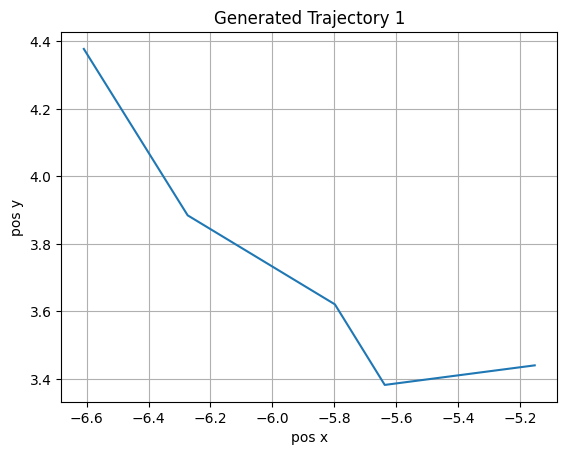

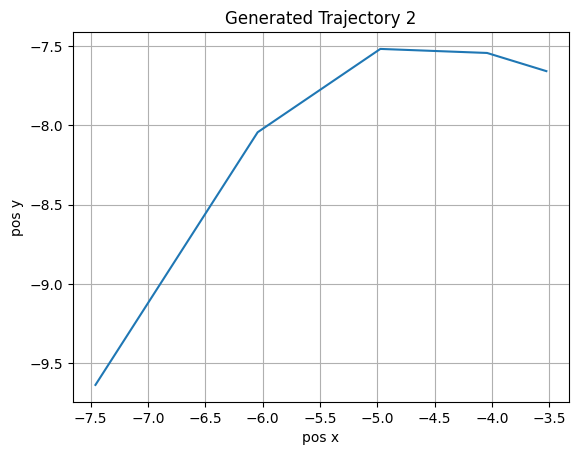

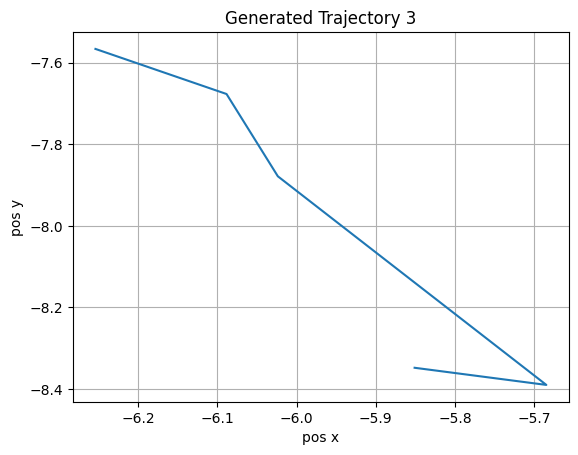

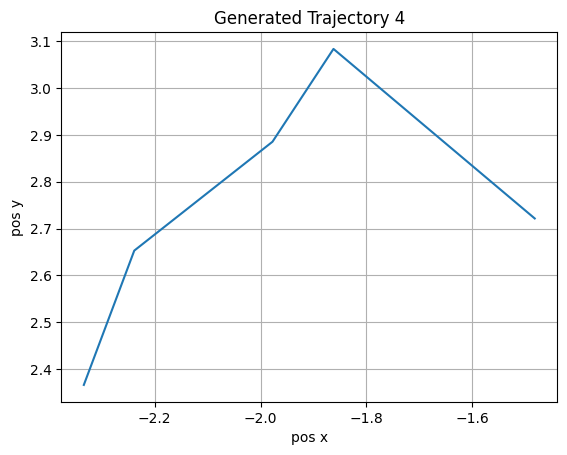

In [ ]:
# Sampling and plotting
samples = trained_diffusion.sample((5, 5, 2), device=device)
for i in range(4):
    plt.plot(samples[i, :, 0].cpu().detach().numpy(), samples[i, :, 1].cpu().detach().numpy()) # Detach the tensor and convert to NumPy
    plt.title(f"Generated Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.show()

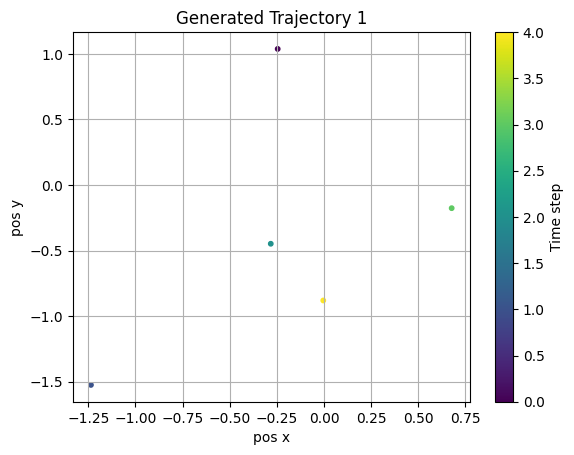

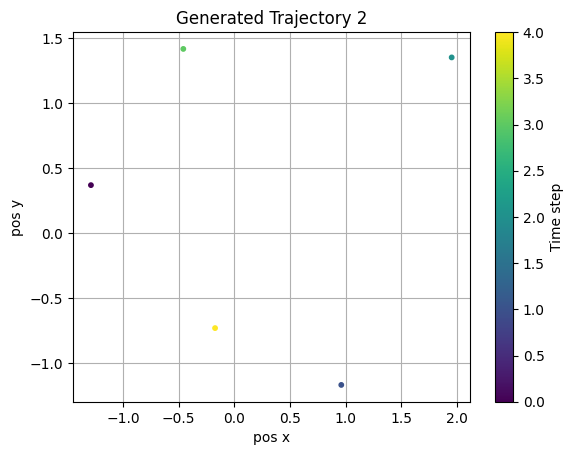

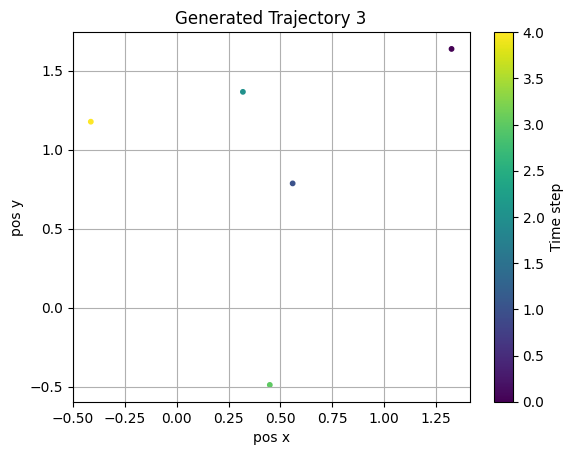

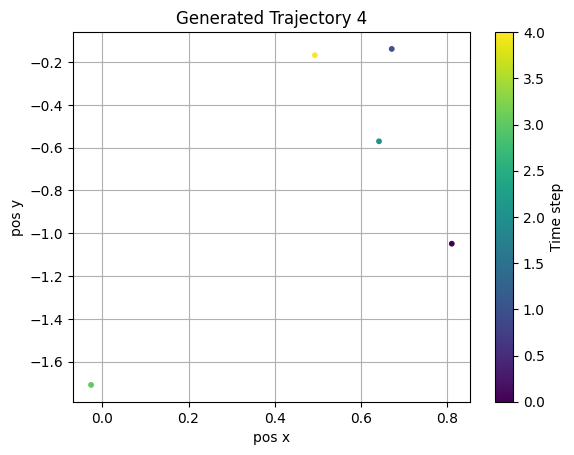

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

samples = trained_diffusion.sample((4, 5, 2), device=device)

for i in range(4):
    x = samples[i, :, 0].cpu().detach().numpy()
    y = samples[i, :, 1].cpu().detach().numpy()
    t = np.arange(len(x))  # Time steps for coloring

    plt.figure()
    scatter = plt.scatter(x, y, c=t, cmap='viridis', s=10)
    plt.colorbar(scatter, label='Time step')
    plt.title(f"Generated Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

samples = trained_diffusion.sample((4, 5, 2), device=device)

for i in range(4):
    x = samples[i, :, 0].cpu().detach().numpy()
    y = samples[i, :, 1].cpu().detach().numpy()

    dx = np.diff(x)
    dy = np.diff(y)

    plt.figure()
    plt.quiver(
        x[:-1], y[:-1], dx, dy,
        np.arange(len(dx)), cmap='viridis', scale_units='xy', angles='xy', scale=1, width=0.003
    )
    plt.plot(x, y, alpha=0.3, linestyle='--')  # optional faded full trajectory line
    plt.colorbar(label='Time step')
    plt.title(f"Generated Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()


NameError: name 'trained_diffusion' is not defined

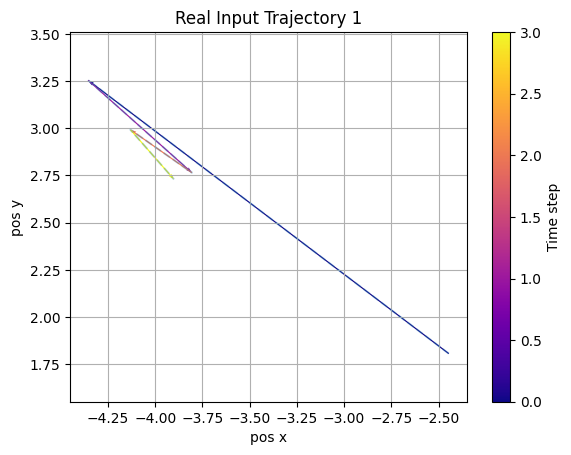

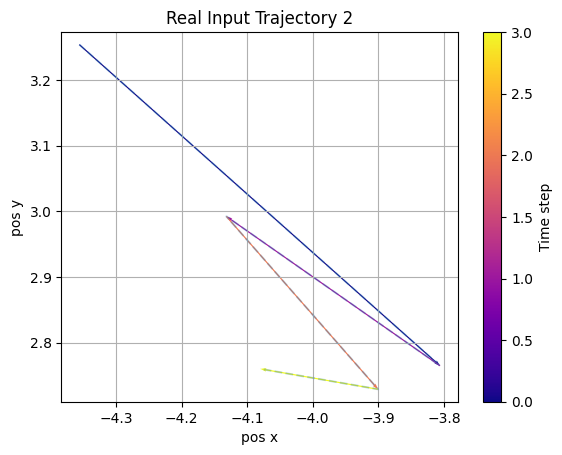

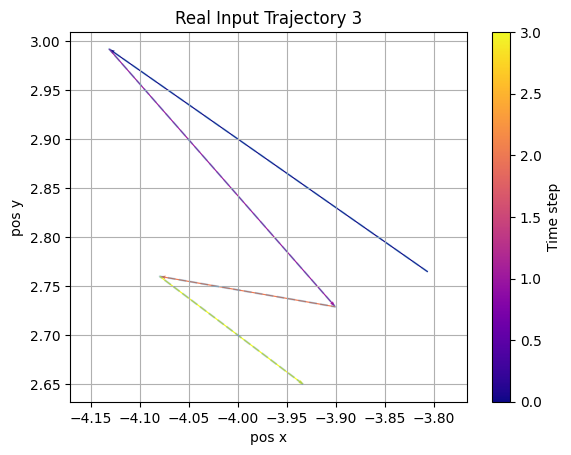

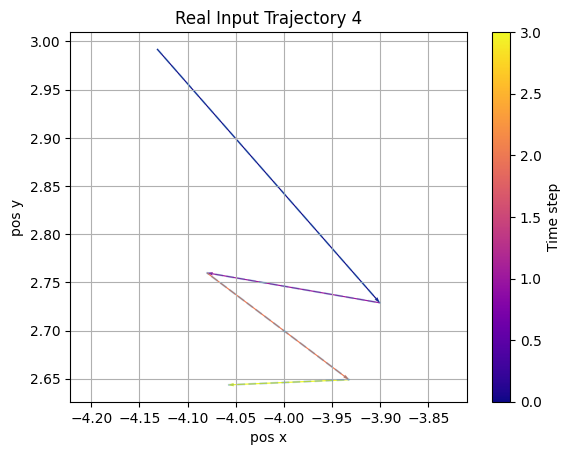

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick N real sequences to plot
N_plot = 4
real_samples = sequences[:N_plot]  # shape: (4, 50, 2)

for i in range(N_plot):
    x = real_samples[i, :, 0]
    y = real_samples[i, :, 1]

    dx = np.diff(x)
    dy = np.diff(y)

    plt.figure()
    plt.quiver(
        x[:-1], y[:-1], dx, dy,
        np.arange(len(dx)), cmap='plasma', scale_units='xy', angles='xy', scale=1, width=0.003
    )
    plt.plot(x, y, alpha=0.3, linestyle='--')
    plt.colorbar(label='Time step')
    plt.title(f"Real Input Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()


In [ ]:

p(xt|xt-1,xt-2,)

NameError: name 'CONVOLUTON' is not defined

In [62]:
test_labels

tensor([7, 7, 8,  ..., 2, 4, 7])

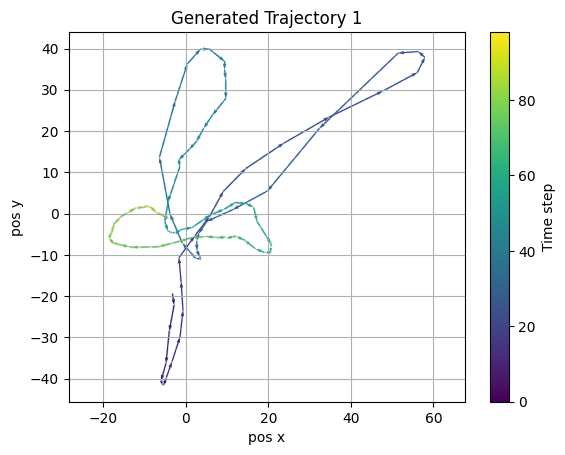

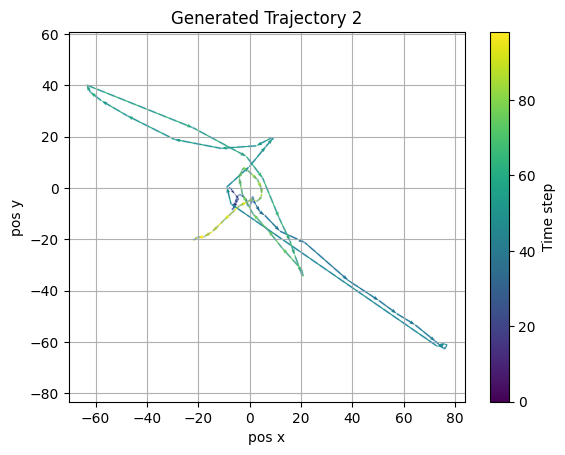

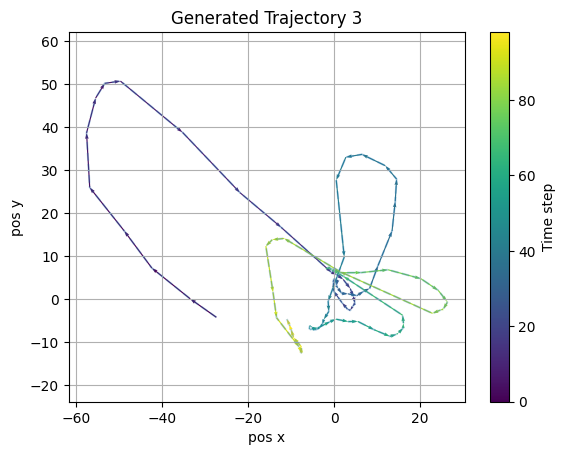

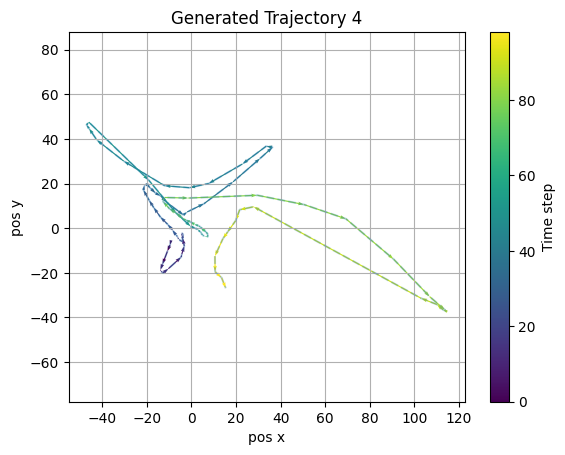

In [104]:
i

samples = trained_diffusion.sample((4, 100, 2), device=device)


for i in range(4):
    x = samples[i, :, 0].cpu().detach().numpy()
    y = samples[i, :, 1].cpu().detach().numpy()

    dx = np.diff(x)
    dy = np.diff(y)

    plt.figure()
    plt.quiver(
        x[:-1], y[:-1], dx, dy,
        np.arange(len(dx)), cmap='viridis', scale_units='xy', angles='xy', scale=1, width=0.003
    )
    plt.plot(x, y, alpha=0.3, linestyle='--')  # optional faded full trajectory line
    plt.colorbar(label='Time step')
    plt.title(f"Generated Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

samples = trained_diffusion.sample((4, 10, 2), device=device)

for i in range(4):
    x = samples[i, :, 0].cpu().detach().numpy()
    y = samples[i, :, 1].cpu().detach().numpy()

    dx = np.diff(x)
    dy = np.diff(y)

    plt.figure()
    plt.quiver(
        x[:-1], y[:-1], dx, dy,
        np.arange(len(dx)), cmap='viridis', scale_units='xy', angles='xy', scale=1, width=0.003
    )
    plt.plot(x, y, alpha=0.3, linestyle='--')  # optional faded full trajectory line
    plt.colorbar(label='Time step')
    plt.title(f"Generated Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()


NameError: name 'trained_diffusion' is not defined

In [ ]:
def sample_from_timestamp(self, timestamp, trial_df, T=100, device="cuda"):
    match = trial_df[(trial_df["start_time"] <= timestamp) & (timestamp <= trial_df["stop_time"])]
    if match.empty:
        raise ValueError(f"No trial found for timestamp {timestamp}")

    trial_row = match.iloc[0]

    # sample a trajectory
    x = torch.randn((1, T, 2), device=device)
    for t in reversed(range(self.timesteps)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)
        predicted_noise = self.model(x, t_batch)
        beta_t = self.betas[t]
        alpha_t = self.alphas[t]
        alpha_bar_t = self.alphas_cumprod[t]
        x = (1 / torch.sqrt(alpha_t)) * (
            x - beta_t / torch.sqrt(1 - alpha_bar_t) * predicted_noise
        )
        if t > 0:
            x += torch.sqrt(beta_t) * torch.randn_like(x)
    return x.squeeze(0).cpu(), trial_row


In [83]:
test_df = cursordf

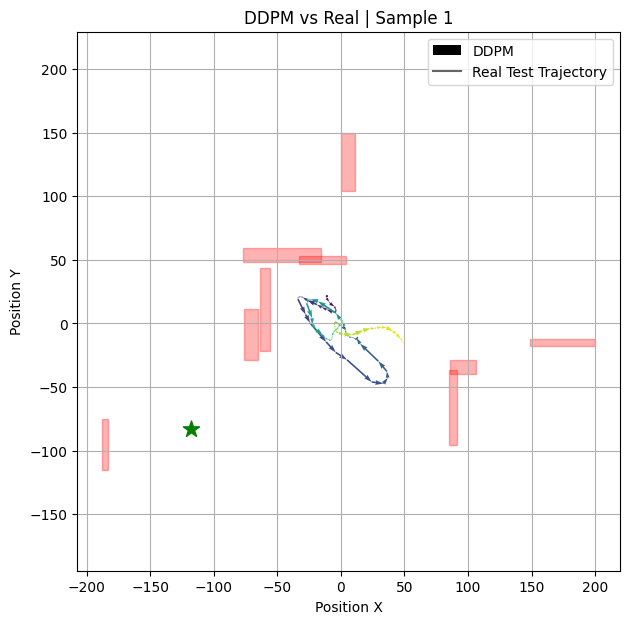

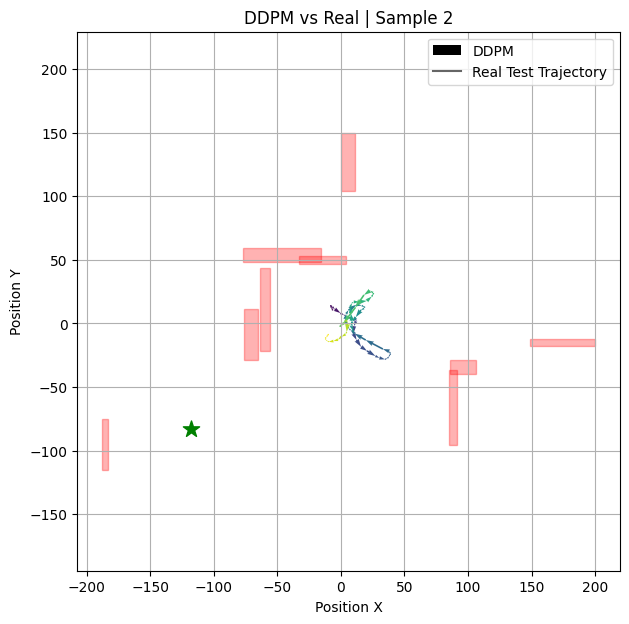

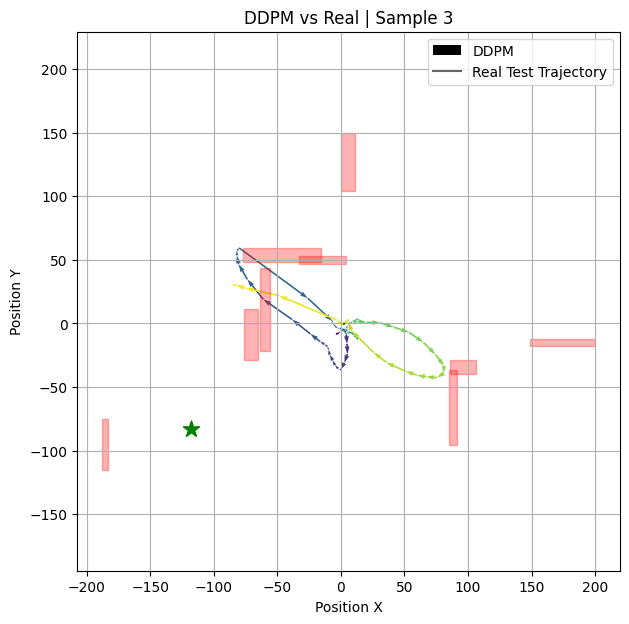

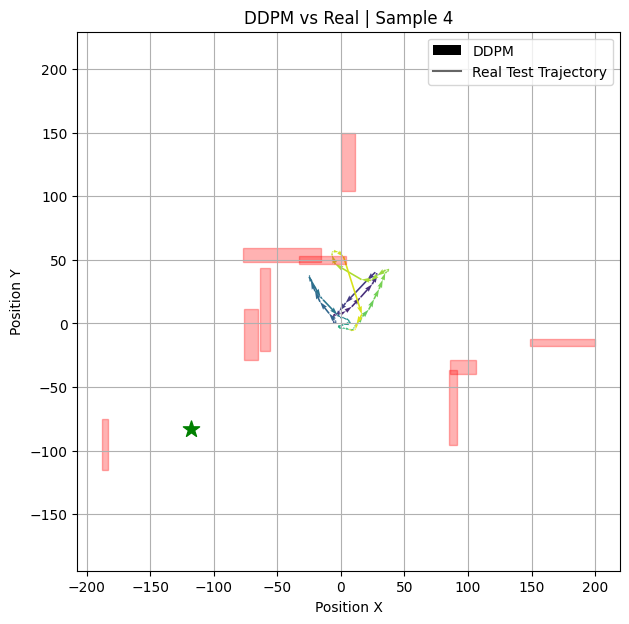

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import re

# --- Parsing helper ---
def parse_np_array(s):
    if pd.isna(s) or s.strip() == "[]":
        return np.empty((0, 4), dtype=int)

    try:
        rows = s.strip()[1:-1].split('\n')
        parsed = []
        for row in rows:
            cleaned = re.sub(r'[\[\]]', '', row.strip())
            cleaned = re.sub(r'\s+', ' ', cleaned)
            parsed.append(np.fromstring(cleaned, sep=' ', dtype=int))
        return np.vstack(parsed)
    except:
        return np.empty((0, 4), dtype=int)

# --- Plotting ---
samples = trained_diffusion.sample((5, 100, 2), device=device)

for i in range(4):
    # 1. Sampled DDPM
    x = samples[i, :, 0].cpu().detach().numpy()
    y = samples[i, :, 1].cpu().detach().numpy()
    dx = np.diff(x)
    dy = np.diff(y)

    # 2. Real sample
    real = test_data[i].cpu().detach().numpy()
    x_real = real[:, 0]
    y_real = real[:, 1]

    # 3. Timestamp → trial match
    timestamp = test_df.iloc[i]['timestamp']  # Make sure test_df has timestamp
    match = trial[(trial['start_time'] <= timestamp) & (timestamp <= trial['stop_time'])]

    if not match.empty:
        row = match.iloc[0]
        barriers = parse_np_array(row["barrier_pos"])
        targets = parse_np_array(row["target_pos"])
    else:
        barriers = np.empty((0, 4))
        targets = np.empty((0, 2))

    # 4. Plot everything
    plt.figure(figsize=(7, 7))
    plt.quiver(x[:-1], y[:-1], dx, dy, np.arange(len(dx)), cmap='viridis', scale_units='xy', angles='xy', scale=1, width=0.003, label='DDPM')
    # plt.plot(x, y, linestyle='-', alpha=0.3)

    plt.plot(x_real, y_real, '-', color='black', alpha=0.6, label="Real Test Trajectory")

    # Barriers
    for b in barriers:
        if len(b) == 4:
            plt.gca().add_patch(plt.Rectangle((b[0], b[1]), b[2], b[3], color='red', alpha=0.3))

    # Targets
    for t in targets:
        if len(t) >= 2:
            plt.scatter(t[0], t[1], marker='*', color='green', s=150)

    plt.title(f"DDPM vs Real | Sample {i+1}")
    plt.xlabel("Position X")
    plt.ylabel("Position Y")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()


In [ ]:
validation
maze - overlayt trajectory

NameError: name 'validation' is not defined

In [76]:
cursordf = pd.read_csv("matched_pos.csv")

In [79]:
cursordf["barrier_pos"][0]

'[[ -33   47   37    6]\n [ -77   48   61   11]\n [ -64  -22    8   66]\n [-188 -115    5   40]\n [   0  104   11   46]\n [  86  -40   20   11]\n [  85  -96    6   59]\n [ 149  -18   51    6]\n [ -76  -29   11   40]]'

In [77]:
cursordf

,Unnamed: 0,timestamp,cursor_pos,cursor_pos.1,trial_type,barrier_pos,target_pos
0,0,0.001,-2.445709,1.806509,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
1,1,0.002,-4.355809,3.254141,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
2,2,0.003,-3.806004,2.764535,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
3,3,0.004,-4.131651,2.992293,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
4,4,0.005,-3.900459,2.728821,11.0,[[ -33 47 37 6]\n [ -77 48 61 11]...,[[-118 -83]]
...,...,...,...,...,...,...,...
58729,58729,58.730,-113.721973,-77.212775,7.0,[],[[-92 81]]
58730,58730,58.731,-120.190982,-81.605331,7.0,[],[[-92 81]]
58731,58731,58.732,-110.952083,-75.406750,7.0,[],[[-92 81]]
58732,58732,58.733,-126.427600,-85.791460,7.0,[],[[-92 81]]


In [78]:


data = np.load("trajectory_dataset.npz", allow_pickle=True)


# Extract test_labels and convert to torch tensor
test_labels = torch.tensor(data["test_labels"], dtype=torch.long)
test_data = torch.tensor(data["test"].astype(np.float32), dtype=torch.float32)
n_samples = 5

# Random indices to sample from
indices = torch.randint(0, test_data.size(0), (n_samples,))

# Sample trajectories and labels
sampled_trajectories = test_data[indices]
sampled_labels = test_labels[indices]

29.7


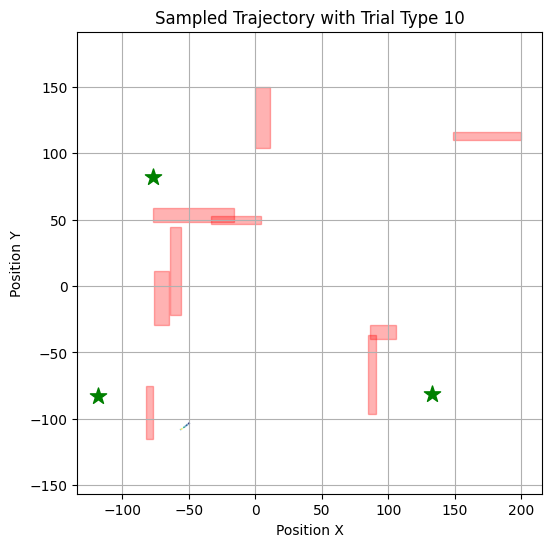

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import re

# Step 0: Ensure your inputs are defined
# sampled_trajectories, sampled_labels, and the enriched DataFrame `data`

# Step 1: Select first sampled trajectory and its label
first_trajectory = sampled_trajectories[0].cpu().numpy()
first_label = sampled_labels[0].item()

# Step 2: Find the corresponding trial row with same trial_type
matched_row = cursordf[cursordf['trial_type'] == first_label].iloc[0]

# Step 3: Parse stringified arrays into NumPy arrays
def parse_np_array(s):
    if pd.isna(s) or s.strip() == "[]":
        return np.empty((0, 4), dtype=int)

    try:
        # Clean up: remove brackets, fix spacing, then reshape
        rows = s.strip()[1:-1].split('\n')
        parsed = []
        for row in rows:
            cleaned = re.sub(r'[\[\]]', '', row.strip())
            cleaned = re.sub(r'\s+', ' ', cleaned)
            parsed.append(np.fromstring(cleaned, sep=' ', dtype=int))
        return np.vstack(parsed)
    except:
        return np.empty((0, 4), dtype=int)

barriers = parse_np_array(matched_row["barrier_pos"])
targets = parse_np_array(matched_row["target_pos"])
timestamp = matched_row["timestamp"]
print(timestamp)

# Step 4: Plot the sampled trajectory + associated environment
x = first_trajectory[:, 0]
y = first_trajectory[:, 1]
dx = np.diff(x)
dy = np.diff(y)

plt.figure(figsize=(6, 6))
plt.quiver(
    x[:-1], y[:-1], dx, dy,
    np.arange(len(dx)), cmap='viridis', scale_units='xy', angles='xy', scale=1, width=0.003
)
plt.plot(x, y, alpha=0.3, linestyle='--', label="Trajectory")

# Plot barriers
for b in barriers:
    if len(b) == 4:
        plt.gca().add_patch(plt.Rectangle((b[0], b[1]), b[2], b[3], color='red', alpha=0.3))

# Plot targets
for t in targets:
    if len(t) >= 2:
        plt.scatter(t[0], t[1], marker='*', color='green', s=150)

plt.title(f"Sampled Trajectory with Trial Type {first_label}")
plt.xlabel("Position X")
plt.ylabel("Position Y")
plt.axis("equal")
plt.grid(True)
plt.show()


In [ ]:
trial = pd.read_csv()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

samples = trained_diffusion.sample((4, 10, 2), device=device)

for i in range(4):
    x = samples[i, :, 0].cpu().detach().numpy()
    y = samples[i, :, 1].cpu().detach().numpy()

    dx = np.diff(x)
    dy = np.diff(y)

    plt.figure()
    plt.quiver(
        x[:-1], y[:-1], dx, dy,
        np.arange(len(dx)), cmap='viridis', scale_units='xy', angles='xy', scale=1, width=0.003
    )
    plt.plot(x, y, alpha=0.3, linestyle='--')  # optional faded full trajectory line
    plt.colorbar(label='Time step')
    plt.title(f"Generated Trajectory {i+1}")
    plt.xlabel("pos x")
    plt.ylabel("pos y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()


In [96]:
def generate_trajectory_from_timestamp(diffusion_model, timestamp, trial_df, T=100, device="cuda"):
    """
    Generates a DDPM trajectory aligned with the environment (barriers/targets)
    active at a given timestamp.

    Args:
        diffusion_model: your trained GaussianDiffusion model
        timestamp (float): timestamp of the real trajectory
        trial_df (pd.DataFrame): trial data with start_time, stop_time, barrier_pos, target_pos
        T (int): number of trajectory steps
        device (str): "cuda" or "cpu"

    Returns:
        trajectory (np.ndarray): shape (T, 2)
        barrier_pos (np.ndarray): shape (n, 4)
        target_pos (np.ndarray): shape (m, 2 or 4)
    """
    import re

    # Find the trial active at this timestamp
    match = trial_df[(trial_df['start_time'] <= timestamp) & (timestamp <= trial_df['stop_time'])]
    if match.empty:
        raise ValueError(f"No matching trial found for timestamp {timestamp}")

    row = match.iloc[0]

    def parse_np_array(s):
        if pd.isna(s) or s.strip() == "[]":
            return np.empty((0, 4), dtype=int)
        rows = s.strip()[1:-1].split('\n')
        parsed = []
        for r in rows:
            cleaned = re.sub(r'[\[\]]', '', r.strip())
            cleaned = re.sub(r'\s+', ' ', cleaned)
            parsed.append(np.fromstring(cleaned, sep=' ', dtype=int))
        return np.vstack(parsed)

    barrier_pos = parse_np_array(row["barrier_pos"])
    target_pos = parse_np_array(row["target_pos"])

    # Generate trajectory using DDPM
    x = torch.randn((1, T, 2), device=device)
    for t in reversed(range(diffusion_model.timesteps)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)
        predicted_noise = diffusion_model.model(x, t_batch)
        beta_t = diffusion_model.betas[t]
        alpha_t = diffusion_model.alphas[t]
        alpha_bar_t = diffusion_model.alphas_cumprod[t]
        x = (1 / torch.sqrt(alpha_t)) * (
            x - beta_t / torch.sqrt(1 - alpha_bar_t) * predicted_noise
        )
        if t > 0:
            x += torch.sqrt(beta_t) * torch.randn_like(x)

    # return x.squeeze(0).cpu().numpy(), barrier_pos, target_pos
    return x.squeeze(0).cpu().detach().numpy(), barrier_pos, target_pos


In [97]:
timestamp = matched_row["timestamp"]  # or any timestamp from real data
ddpm_traj, barriers, targets = generate_trajectory_from_timestamp(
    trained_diffusion, timestamp, trial_df=trial, T=first_trajectory.shape[0], device=device
)


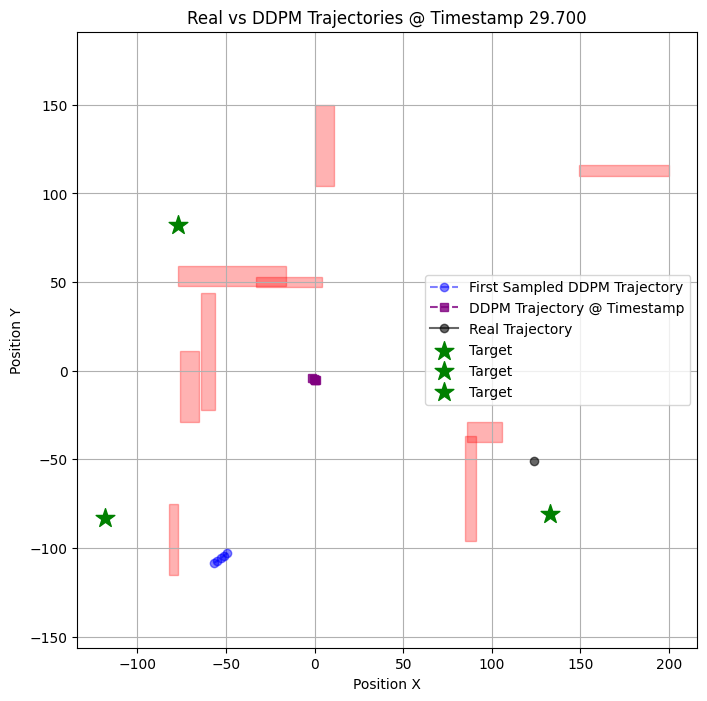

In [98]:

import matplotlib.pyplot as plt

# --- Step 1: Extract coordinates ---
# Original first sampled DDPM trajectory
x_first = first_trajectory[:, 0]
y_first = first_trajectory[:, 1]

# Freshly generated DDPM trajectory at timestamp
x_ddpm = ddpm_traj[:, 0]
y_ddpm = ddpm_traj[:, 1]

# Real trajectory points
real_traj_points = cursordf[cursordf['timestamp'] == timestamp]
real_x = real_traj_points['cursor_pos'].values
real_y = real_traj_points['cursor_pos.1'].values

# --- Step 2: Start plotting ---
plt.figure(figsize=(8, 8))

# Plot original first DDPM sampled trajectory
plt.plot(x_first, y_first, 'o--', alpha=0.5, label="First Sampled DDPM Trajectory", color='blue')

# Plot DDPM trajectory generated at timestamp
plt.plot(x_ddpm, y_ddpm, 's--', alpha=0.8, label="DDPM Trajectory @ Timestamp", color='purple')

# Plot real trajectory
plt.plot(real_x, real_y, 'o-', alpha=0.6, label="Real Trajectory", color='black')

# Plot barriers
for b in barriers:
    if len(b) == 4:
        plt.gca().add_patch(plt.Rectangle((b[0], b[1]), b[2], b[3], color='red', alpha=0.3))

# Plot targets
for t in targets:
    if len(t) >= 2:
        plt.scatter(t[0], t[1], marker='*', color='green', s=200, label='Target')

# --- Step 3: Final plot settings ---
plt.title(f"Real vs DDPM Trajectories @ Timestamp {timestamp:.3f}")
plt.xlabel("Position X")
plt.ylabel("Position Y")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()
